In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sklearn
%matplotlib inline

In [7]:
#importing the dataset
df_train = pd.read_csv('D:\\Black Friday Data\\train.csv')
df_test = pd.read_csv('D:\\Black Friday Data\\test.csv')

In [10]:
df_test.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3'],
      dtype='object')

## PROBLEM STATEMENT
--------------------
A retail company, ABC Private Limited, wants to understand customer purchase behaviour (specifically purchase amount) across various products of different categories. They have shared a dataset containing purchase summaries of customers for selected high‑volume products from last month. The dataset also includes customer demographics (age, gender, marital status, city type, stay in current city), product details (product ID and product category), and the total purchase amount from last month. The company now wants to build a predictive model to estimate the purchase amount of customers for different products, which will help them design personalized offers.”

In [71]:
#Merge both train and test datasets to perform EDA on the entire dataset
final_df = pd.concat([df_train, df_test], ignore_index=True)

In [72]:
final_df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [20]:
len(final_df)

783667

In [58]:
df = df_train.merge(df_test, how='outer', on=['User_ID', 'Product_ID'])
df.head(5)

,User_ID,Product_ID,Gender_x,Age_x,Occupation_x,City_Category_x,Stay_In_Current_City_Years_x,Marital_Status_x,Product_Category_1_x,Product_Category_2_x,...,Purchase,Gender_y,Age_y,Occupation_y,City_Category_y,Stay_In_Current_City_Years_y,Marital_Status_y,Product_Category_1_y,Product_Category_2_y,Product_Category_3_y
0,1000001,P00000142,F,0-17,10.0,A,2,0.0,3.0,4.0,...,13650.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000001,P00004842,F,0-17,10.0,A,2,0.0,3.0,4.0,...,13645.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000001,P00025442,F,0-17,10.0,A,2,0.0,1.0,2.0,...,15416.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000001,P00051442,F,0-17,10.0,A,2,0.0,8.0,17.0,...,9938.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000001,P00051842,F,0-17,10.0,A,2,0.0,4.0,8.0,...,2849.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
len(df)

783667

In [73]:
## Drop the user_id column as it is not required for analysis and modeling
final_df.drop(['User_ID'], axis=1, inplace=True)

In [74]:
#Changing the Gender column to categorical type to Numerical type for analysis and modeling
#final_df['Gender'] = final_df['Gender'].map({'M': 1, 'F': 0})
final_df['Gender'] = final_df['Gender'].replace({'M':1, 'F':0})
final_df.head(5)

C:\Users\PC\AppData\Local\Temp\ipykernel_8532\1945466758.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df['Gender'] = final_df['Gender'].replace({'M':1, 'F':0})


,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [64]:
final_df['Age'].unique()


array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [77]:
City_Category_df=pd.get_dummies(final_df['City_Category'], prefix='City_Category', drop_first=True)

In [75]:
final_df['Age'] = final_df['Age'].replace({'0-17':1, '18-25':2, '26-35':3, '36-45':4, '46-50':5, '51-55':6, '55+':7})
final_df.head(5)

C:\Users\PC\AppData\Local\Temp\ipykernel_8532\2310216794.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df['Age'] = final_df['Age'].replace({'0-17':1, '18-25':2, '26-35':3, '36-45':4, '46-50':5, '51-55':6, '55+':7})


,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0


In [ ]:
#Second technique to convert categorical data to numerical data is to use the LabelEncoder class from the sklearn library. This class can be used to convert categorical data into numerical data by assigning a unique integer value to each category.
#example for the age column, we can use the LabelEncoder class to convert the age categories into numerical values as follows:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()         
final_df['Age'] = le.fit_transform(final_df['Age'])
final_df.head(5)

In [78]:
City_Category_df.head(5)

,City_Category_B,City_Category_C
0,False,False
1,False,False
2,False,False
3,False,False
4,False,True


In [80]:
final_df = pd.concat([final_df, City_Category_df], axis=1)
final_df.drop(['City_Category'], axis=1, inplace=True)
final_df.head(5)

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,City_Category_B,City_Category_C
0,P00069042,0,1,10,2,0,3,NaN,NaN,8370.0,False,False
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,False,False
2,P00087842,0,1,10,2,0,12,NaN,NaN,1422.0,False,False
3,P00085442,0,1,10,2,0,12,14.0,NaN,1057.0,False,False
4,P00285442,1,7,16,4+,0,8,NaN,NaN,7969.0,False,True


In [90]:
#Missing Values in the dataset
final_df.isnull().sum()

Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
City_Category_B               0
City_Category_C               0
dtype: int64

In [87]:
final_df['Product_Category_2'].unique()

array([ 8.,  6., 14.,  2., 15., 16., 11.,  5.,  3.,  4., 12.,  9., 10.,
       17., 13.,  7., 18.])

In [85]:
final_df['Product_Category_2'].mode()

0    8.0
Name: Product_Category_2, dtype: float64

In [89]:
##Focus on replacing the missing values in the Product_Category_2 and Product_Category_3 columns with the mode of the respective columns. The mode is the most frequently occurring value in a column and can be used to fill in missing values.
final_df['Product_Category_2'].fillna(final_df['Product_Category_2'].mode()[0], inplace=True)
final_df['Product_Category_3'].fillna(final_df['Product_Category_3'].mode()[0], inplace=True) 
final_df['Purchase'].fillna(final_df['Purchase'].mode()[0], inplace=True)       

C:\Users\PC\AppData\Local\Temp\ipykernel_8532\1803318017.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Product_Category_2'].fillna(final_df['Product_Category_2'].mode()[0], inplace=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_8532\1803318017.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [92]:
final_df.shape

(783667, 12)

In [93]:
final_df.columns

Index(['Product_ID', 'Gender', 'Age', 'Occupation',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase',
       'City_Category_B', 'City_Category_C'],
      dtype='object')

In [99]:
# Replacing the values in the Stay_In_Current_City_Years column with numerical values. The values in this column are currently represented as strings, with the value '4+' representing 4 or more years. We will replace this value with 4 to make it easier to work with the data. 
final_df['Stay_In_Current_City_Years'].replace({'4+': 4}, inplace=True)
final_df['Stay_In_Current_City_Years'].value_counts()

C:\Users\PC\AppData\Local\Temp\ipykernel_8532\1583327547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['Stay_In_Current_City_Years'].replace({'4+': 4}, inplace=True)


Stay_In_Current_City_Years
1    276425
2    145427
3    135428
4    120671
0    105716
Name: count, dtype: int64

In [97]:
# Convert object type columns to integers
final_df['Product_Category_1'] = final_df['Product_Category_1'].astype(int)
final_df['Product_Category_2'] = final_df['Product_Category_2'].astype('Float64')
final_df['Product_Category_3'] = final_df['Product_Category_3'].astype('Float64') 

In [100]:
final_df.dtypes

Product_ID                     object
Gender                          int64
Age                             int64
Occupation                      int64
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            Float64
Product_Category_3            Float64
Purchase                      float64
City_Category_B                  bool
City_Category_C                  bool
dtype: object

<Axes: xlabel='Age', ylabel='Purchase'>

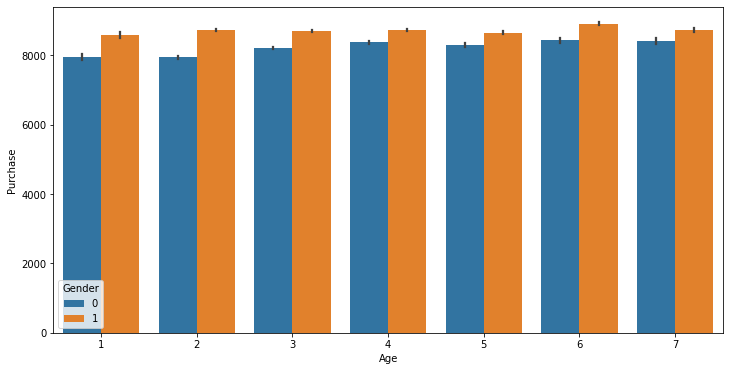

In [104]:
# Visualization
plt.rcParams['figure.figsize'] = (12, 6)
sns.barplot(x='Age', y='Purchase', hue='Gender', data=final_df)

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

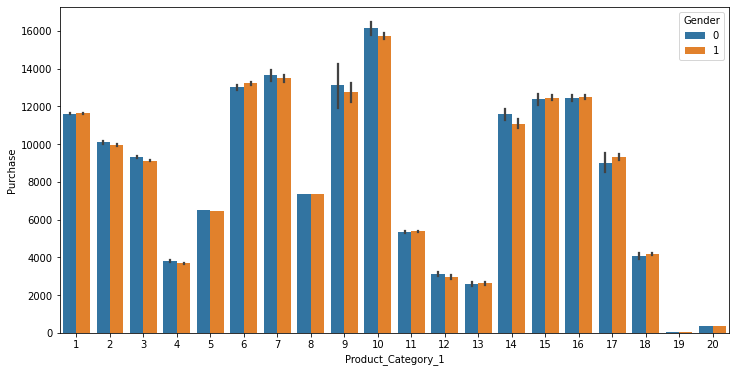

In [105]:
plt.rcParams['figure.figsize'] = (12, 6)
sns.barplot(x='Product_Category_1', y='Purchase', hue='Gender', data=final_df)

In [106]:
##Feature Scaling is a technique to standardize the independent features present in the data in a fixed range. It is also known as data normalization and is generally performed during the data preprocessing step. The main objective of feature scaling is to normalize the data within a particular range. This can be done using various techniques such as Min-Max Scaling, Standardization, and Robust Scaling.
df_test = final_df[final_df['Purchase'].isnull()] # where purchase is null
df_train = final_df[~final_df['Purchase'].isnull()] # where purchase has values

In [116]:
X =df_train.drop(['Purchase'], axis=1)
X.head()
X.shape

(783667, 11)

In [129]:
Y=df_train['Purchase']
Y.shape


(783667,)

In [130]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.33, random_state=42)

In [131]:
X_train.drop('Product_ID', axis=1, inplace=True)
X_test.drop('Product_ID', axis=1, inplace=True)

In [132]:
##feature scaling
from sklearn.preprocessing import StandardScaler    
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [133]:
#train your data using any model of your choice. For example, you can use a Random Forest Regressor to train your data as follows:
from sklearn.ensemble import RandomForestRegressor  
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

KeyboardInterrupt: 